# 03. Risk model, policy rules and triage decisions

**Purpose.** Train the credit risk model, check it is accurate and honest about its uncertainty, explain its decisions, and run the full triage (data quality, model, policy, broker note) on the live queue.

Code: `src/metro_deal_desk/` (`validation.py`, `features.py`, `model.py`, `policy.py`, `decision.py`, `pipeline.py`). All data is synthetic (see notebook 02).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from metro_deal_desk import model, validation, decision, pipeline, policy
from metro_deal_desk.features import build_features, NUMERIC, CATEGORIES

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
BAR, HI = "#3b6ea5", "#c8553d"
history = pd.read_csv("../data/synthetic/applications_history.csv")

## 1. Train the model

LightGBM (gradient boosted trees) is the standard choice for credit data in tables. Two design choices:

- **Time-based test set.** The model trains on older applications and is tested on the newest 20%, the way a lender would actually use it. A random split would flatter it.
- **Monotone constraints.** The model is forced to respect basic credit logic whatever the data suggests: a better credit score or a longer trading history can never raise risk; a higher loan-to-value ratio, an older asset at the end of the term or a balloon above resale value can never lower it. This keeps its behaviour explainable to credit staff and auditors.

Features with no credit rationale (state, entity type, channel) are deliberately left out, even if they add a little accuracy.

In [2]:
booster, card, (train_df, test_df, p_test) = model.train(history, save=True)
{k: card[k] for k in ["trained_on", "validated_on", "tested_on", "test_auc", "test_brier", "test_default_rate", "mean_predicted_pd"]}

{'trained_on': '13,600 synthetic applications (2023-10-01 to 2025-07-31)',
 'validated_on': '2,400 applications for early stopping (2025-07-31 to 2025-11-29)',
 'tested_on': '4,000 newer applications (2025-11-29 to 2026-06-21)',
 'test_auc': 0.728,
 'test_brier': 0.046,
 'test_default_rate': 0.0505,
 'mean_predicted_pd': 0.0487}

### Baseline comparison

A plain logistic regression on the same features and the same split. The boosted model should do at least as well; if it did not, the simpler model would be the better choice.

In [3]:
Xtr, Xte = build_features(train_df), build_features(test_df)
lr = make_pipeline(ColumnTransformer([("num", StandardScaler(), NUMERIC),
                                      ("cat", OneHotEncoder(handle_unknown="ignore"), list(CATEGORIES))]),
                   LogisticRegression(max_iter=2000))
lr.fit(Xtr, train_df["defaulted"])
p_lr = lr.predict_proba(Xte)[:, 1]
pd.DataFrame({
    "AUC (higher is better)": [roc_auc_score(test_df["defaulted"], p_lr), card["test_auc"]],
    "Brier score (lower is better)": [brier_score_loss(test_df["defaulted"], p_lr), card["test_brier"]],
}, index=["Logistic regression", "LightGBM"])

,AUC (higher is better),Brier score (lower is better)
Logistic regression,0.723,0.046
LightGBM,0.728,0.046


**Reading the result.** The boosted model is only slightly ahead of logistic regression. That is a normal and useful finding: in credit, a simple model that is nearly as accurate is often preferred because it is easier to explain and govern. LightGBM is kept here because the monotone constraints give the same guarantees of sensible behaviour, and its explanations are exact. Both sit below the ceiling of about 0.79 set by the randomness built into the data (notebook 02).

## 2. Is the predicted probability trustworthy?

Pricing and decisions use the probability itself, not just the ranking, so it needs to be **calibrated**: of the applications given a 10% probability of default, about 10% should actually default. The chart groups the test set into ten equal bands by predicted probability.

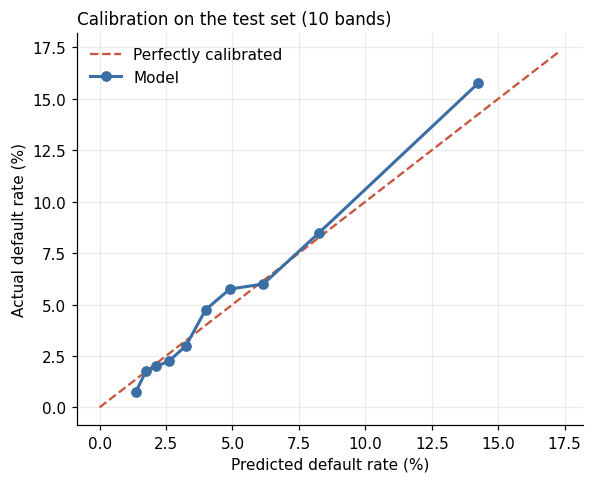

In [4]:
t = test_df.assign(pd_=p_test)
t["band"] = pd.qcut(t["pd_"], 10, labels=False)
cal = t.groupby("band").agg(predicted=("pd_", "mean"), actual=("defaulted", "mean"), n=("pd_", "size"))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
lim = [0, cal[["predicted", "actual"]].max().max() * 100 * 1.1]
ax.plot(lim, lim, color=HI, ls="--", lw=1.5, label="Perfectly calibrated")
ax.plot(cal["predicted"] * 100, cal["actual"] * 100, color=BAR, lw=2, marker="o", ms=6, label="Model")
ax.set_xlabel("Predicted default rate (%)"); ax.set_ylabel("Actual default rate (%)")
ax.set_title("Calibration on the test set (10 bands)", loc="left", fontsize=11); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. What drives the model overall?

Average size of each feature's SHAP value across the test set: how much, on average, it moves an application's risk up or down.

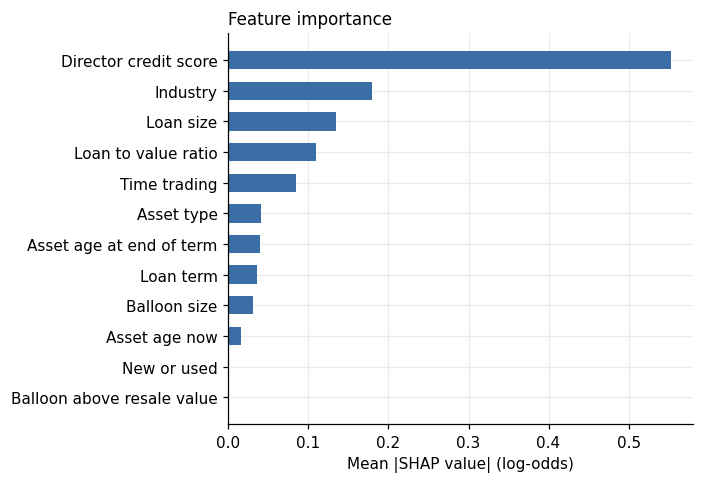

In [5]:
sv = model.shap_values(test_df, booster)
imp = sv.abs().mean().sort_values()
labels = {"credit_score": "Director credit score", "industry": "Industry", "loan_amount": "Loan size",
          "lvr": "Loan to value ratio", "abn_age_months": "Time trading", "asset_category": "Asset type",
          "asset_age_at_end": "Asset age at end of term", "term_months": "Loan term",
          "balloon_pct": "Balloon size", "asset_age_years": "Asset age now", "condition": "New or used",
          "balloon_gap": "Balloon above resale value"}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh([labels[i] for i in imp.index], imp.values, color=BAR, height=0.6)
ax.set_xlabel("Mean |SHAP value| (log-odds)")
ax.set_title("Feature importance", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

## 4. From probability to decision

Thresholds: probability under **5%** is eligible for automatic approval, **5% to 12%** goes to a credit officer, **12%** or more is declined. The table shows how the newest 4,000 loans would have been split on the model score alone, and how they actually performed.

In [6]:
band = np.where(p_test < decision.APPROVE_BELOW, "Approve",
                np.where(p_test < decision.DECLINE_FROM, "Refer", "Decline"))
view = (test_df.assign(band=band).groupby("band")
        .agg(share_of_applications=("defaulted", lambda s: len(s) / len(test_df)),
             actual_default_rate=("defaulted", "mean"), loans=("defaulted", "size"))
        .reindex(["Approve", "Refer", "Decline"]))
view

,share_of_applications,actual_default_rate,loans
band,,,
Approve,0.660,0.027,2639
Refer,0.275,0.076,1100
Decline,0.065,0.176,261


### Credit policy rules

Fixed rules that apply whatever the score. Limits are illustrative, not any real lender's policy.

In [7]:
pd.DataFrame(policy.POLICY_SUMMARY, columns=["Rule", "Outcome", "Triggered when"])

,Rule,Outcome,Triggered when
0,Balloon limit,refer,"Balloon above 35% (cars, utes), 25% (trucks), 15% (earthmoving, agricultural) or 10% (other)"
1,Trading history,refer,ABN registered under 24 months
2,Asset age at end of term,refer,Asset older than 15 years when the loan ends
3,Loan to value,refer,Loan above 110% of the asset price
4,Credit score floor,decline,Director credit score below 500
5,Automatic decision limit,refer,"Loan above $250,000"


## 5. Data quality validator vs the answer key

The incoming queue has 140 deliberately corrupted submissions (notebook 02). Two questions: does the validator catch them, and does it wrongly flag clean submissions?

The rules were written knowing what kinds of errors to expect, so catching all of them is the minimum bar. The more telling number is **false alarms on clean submissions**, where a real validator usually struggles.

In [8]:
raw = pd.read_csv("../data/synthetic/applications_incoming_raw.csv", dtype={"abn": str, "postcode": str})
truth = pd.read_csv("../data/synthetic/incoming_dq_truth.csv")
v = validation.validate_batch(raw)
m = raw[["application_id"]].join(v.drop(columns="application_id")).merge(truth, how="left", on="application_id")
expected_rule = {"asset_description_typo": "unrecognised_asset"}
m["caught"] = [isinstance(i, str) and expected_rule.get(i, i) in r for i, r in zip(m["injected_issue"], m["dq_rules"])]
by_issue = m[m["injected_issue"].notna()].groupby("injected_issue")["caught"].agg(caught="sum", injected="size")
clean = m[m["injected_issue"].isna()]
print(f"Caught {int(by_issue['caught'].sum())} of {int(by_issue['injected'].sum())} injected problems")
print(f"False alarms on {len(clean):,} clean submissions: {(clean['dq_status'] != 'Pass').sum()}")
by_issue

Caught 140 of 140 injected problems
False alarms on 1,864 clean submissions: 0


,caught,injected
injected_issue,,
abn_checksum_fail,14,14
asset_description_typo,22,22
balloon_exceeds_loan,16,16
duplicate_submission,4,4
invalid_term,18,18
loan_far_above_asset_value,21,21
missing_abn,13,13
new_asset_too_old,15,15
postcode_state_mismatch,17,17


## 6. Three applications end to end

In [9]:
def show(app_id):
    app = raw.loc[raw["application_id"] == app_id].iloc[0].to_dict()
    r = decision.assess(app, booster=booster)
    print(f"{app_id}: {app['asset_description']}, {app['industry']}, loan ${app['loan_amount']:,.0f}")
    pd_text = "not scored" if r["pd"] is None else f"{r['pd']:.1%}"
    print(f"  Data quality: {r['dq_status']}   Decision: {r['decision']}   PD: {pd_text}   Grade: {r['risk_grade']}")
    if r["reasons"]:
        print("  Raises risk:", [x["reason"] for x in r["reasons"]["raises_risk"]])
        print("  Lowers risk:", [x["reason"] for x in r["reasons"]["lowers_risk"]])
    for p in r["policy"]:
        print(f"  Policy ({p['outcome']}): {p['message']}")
    print("  Broker note:", r["broker_note"], "\n")

queue = pipeline.score_queue(raw.head(60))[0]
for d in ["Approve", "Refer", "Returned"]:
    show(queue.loc[queue["decision"] == d, "application_id"].iloc[0])

APP-020001: 2026 Toyota HiAce, Professional services, loan $65,700
  Data quality: Pass   Decision: Approve   PD: 3.2%   Grade: B
  Raises risk: ['Director credit score of 661']
  Lowers risk: ['Business trading for 20.6 years', 'Loan size of $65,700', 'Professional services industry']
  Broker note: Good news: APP-020001 ($65,700 over 36 months) is approved subject to standard settlement documents. Risk grade B. Main strengths: business trading for 20.6 years; loan size of $65,700; professional services industry. 

APP-020004: 2022 Ford Transit Custom, Retail trade, loan $28,700
  Data quality: Pass   Decision: Refer   PD: 8.8%   Grade: D
  Raises risk: ['Retail trade industry', 'Loan size of $28,700', 'Loan is 103% of the asset price']
  Lowers risk: ['Director credit score of 718', 'Asset type: Ute / van']
  Broker note: APP-020004 ($28,700 over 48 months) has been referred to a credit officer, risk grade D. Points they will look at: (1) Retail trade industry. (2) Loan size of $28,7

## 7. Score the whole live queue

Writes `data/scored/scored_queue.csv` (one row per application, ready for the Base44 dashboard) and `data/scored/rejection_log.csv` (every data quality issue found).

In [10]:
out = pipeline.run()
print(out["scored"]["decision"].value_counts().to_string())
print(f"\n{len(out['log'])} data quality issues written to the rejection log")

decision
Approve     990
Refer       757
Decline     139
Returned    118

140 data quality issues written to the rejection log
